# 01_Exploratory_Data_Analysis - Data Science Job Salaries

Week 1 Assignment - Stage 1

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("whitegrid")

# Mount Google Drive if you want (optional)
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Load the dataset
df = pd.read_csv('/content/sample_data/ds_salaries.csv')
print('Shape:', df.shape)
df.head()

Shape: (607, 12)


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
# Set display options to format floats and disable scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)

display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


None

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.00,607.00,607.00,607.00,607.00
mean,303.00,2021.41,324000.06,112297.87,70.92
std,175.37,0.69,1544357.49,70957.26,40.71
min,0.00,2020.00,4000.00,2859.00,0.00
25%,151.50,2021.00,70000.00,62726.00,50.00
50%,303.00,2022.00,115000.00,101570.00,100.00
75%,454.50,2022.00,165000.00,150000.00,100.00
max,606.00,2022.00,30400000.00,600000.00,100.00


In [ ]:
# Check missing values and duplicates
print('Missing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
 Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicate rows: 0


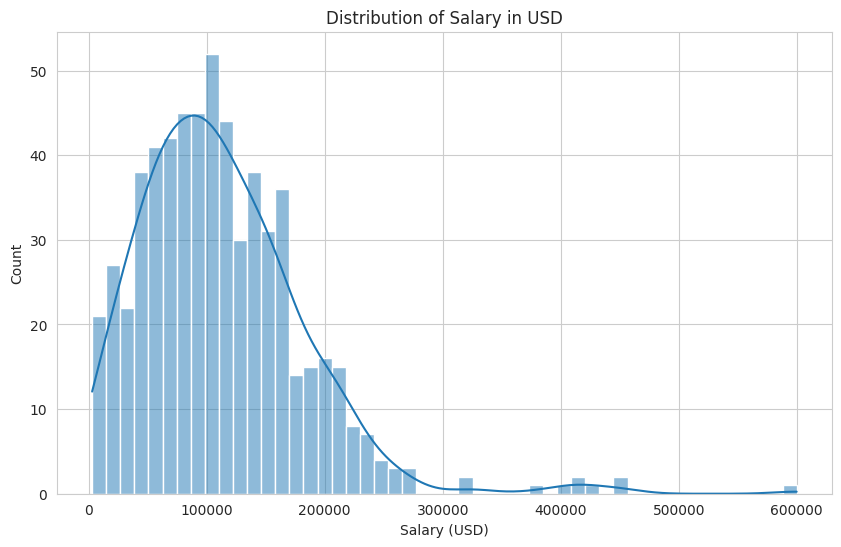

In [ ]:
# Salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], kde=True, bins=50)
plt.title('Distribution of Salary in USD')
plt.xlabel('Salary (USD)')
plt.show()

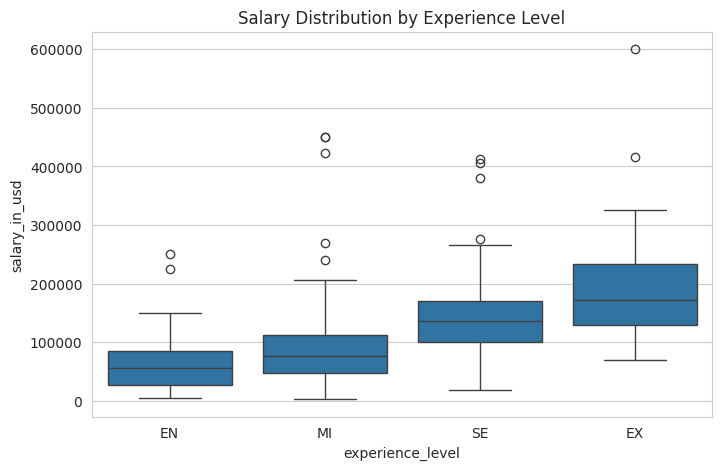

In [ ]:
# Salary by Experience Level
plt.figure(figsize=(8, 5))
order = ['EN', 'MI', 'SE', 'EX']
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, order=order)
plt.title('Salary Distribution by Experience Level')
plt.show()

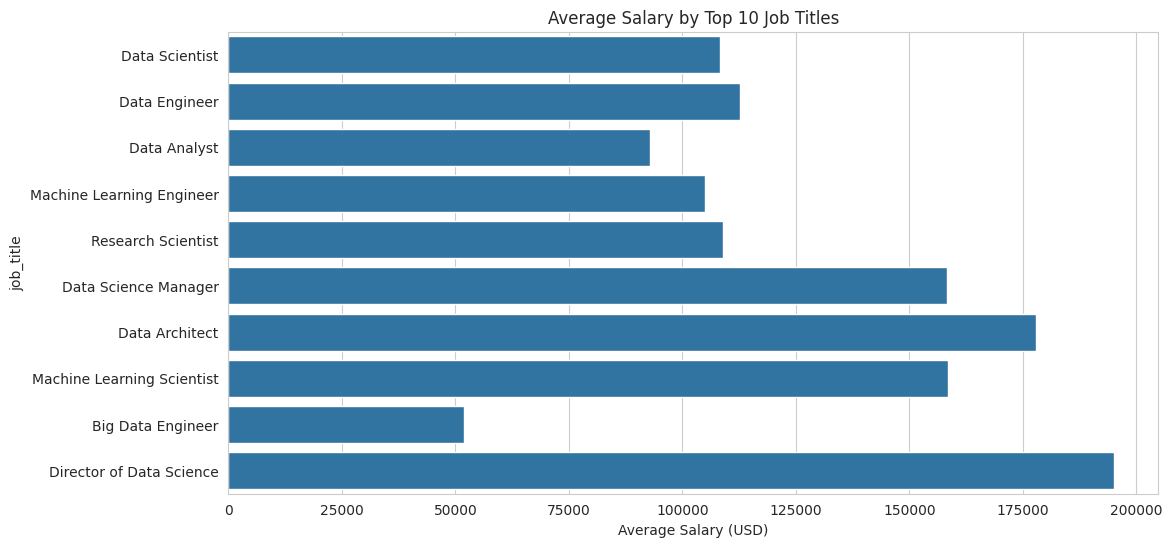

In [ ]:
# Average salary by top job titles
top_jobs = df['job_title'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.barplot(y='job_title', x='salary_in_usd', data=df[df['job_title'].isin(top_jobs)], estimator=np.mean, errorbar=None, order=top_jobs)
plt.title('Average Salary by Top 10 Job Titles')
plt.xlabel('Average Salary (USD)')
plt.show()

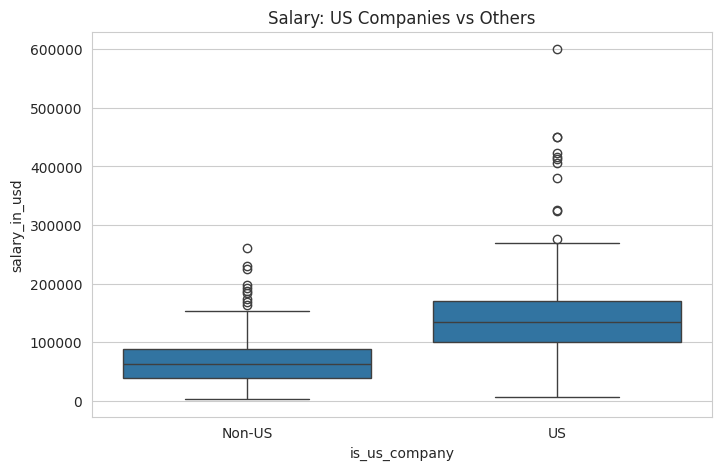

In [ ]:
# US vs Non-US companies
df['is_us_company'] = df['company_location'] == 'US'
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_us_company', y='salary_in_usd', data=df)
plt.title('Salary: US Companies vs Others')
plt.xticks([0, 1], ['Non-US', 'US'])
plt.show()

In [ ]:
print(df['company_location'].value_counts().head(10))

company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64


In [ ]:
corr = df.corr(numeric_only=True)
corr[['salary_in_usd']].sort_values(by='salary_in_usd', ascending=False)

,salary_in_usd
salary_in_usd,1.00
is_us_company,0.53
work_year,0.17
Unnamed: 0,0.17
remote_ratio,0.13
salary,-0.08


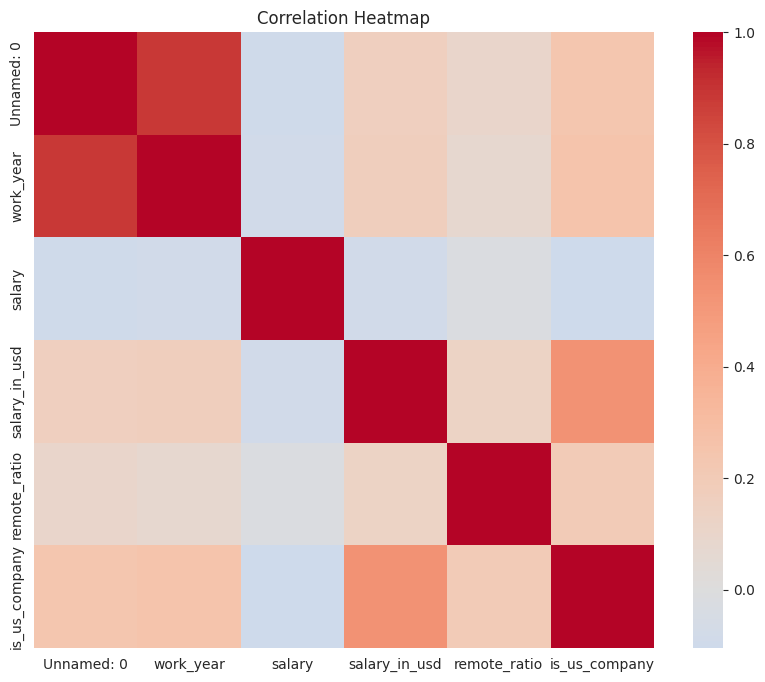

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Percentage of employees living in the same country as the company: 91.60%


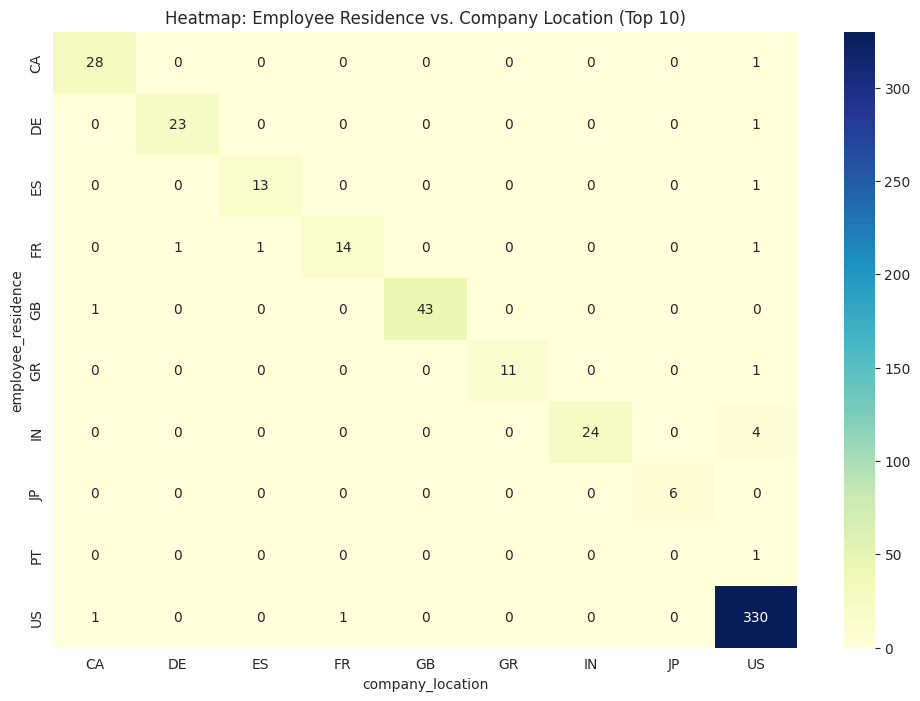

In [25]:
# Calculate the percentage of records where residence matches company location
matching_locations = (df['employee_residence'] == df['company_location']).mean() * 100
print(f'Percentage of employees living in the same country as the company: {matching_locations:.2f}%')

# Create a pivot table for the top 10 residence vs company locations to see the overlap
top_res = df['employee_residence'].value_counts().head(10).index
top_comp = df['company_location'].value_counts().head(10).index

overlap_matrix = pd.crosstab(df[df['employee_residence'].isin(top_res)]['employee_residence'],
                             df[df['company_location'].isin(top_comp)]['company_location'])

plt.figure(figsize=(12, 8))
sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Employee Residence vs. Company Location (Top 10)')
plt.show()